In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# install library
!pip -q install economic_complexity
!pip -q install econci
!pip -q install ecomplexity

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import economic_complexity as ec
import econci
from ecomplexity import ecomplexity
from ecomplexity import proximity

Raw data

In [4]:
root_folder = '/content/drive/MyDrive/Auto Research Team Folder/UNCOMTRADE Data/2022/Hs Conversion From H6 to H5'
trade_name = "Year 2022 HS Corralated Data From H6 to H5.csv"
df_2022 = pd.read_csv(f'{root_folder}/{trade_name}',dtype = {'H5':str})

In [5]:
#drop world as a partner and
df_2022 = df_2022[df_2022.partnerDesc != 'World']
df_2022 = df_2022[df_2022.H5 != '9999']

In [6]:
# split dataframes based on flowcode
imports_df = df_2022[df_2022['flowCode'] == 'M']
exports_df = df_2022[df_2022['flowCode'] == 'X']

In [7]:
exports_df = exports_df[['period','reporterISO','reporterDesc', 'partnerISO', 'partnerDesc','H5','fobvalue']]
exports_df = exports_df.rename(columns={'reporterDesc': 'exporter','reporterISO':'exporterISO', 'partnerDesc': 'importer','partnerISO':'importerISO','H5':'cmdCode', 'fobvalue': 'export_value'})

In [8]:
imports_df = imports_df[['period','reporterISO','reporterDesc','partnerISO', 'partnerDesc','H5','cifvalue']]
imports_df = imports_df.rename(columns={'reporterDesc': 'importer','reporterISO':'importerISO', 'partnerDesc': 'exporter','partnerISO':'exporterISO','H5':'cmdCode','cifvalue':'import_value'})

unprocessed data

In [9]:
trade_data = pd.merge(exports_df, imports_df, on=['period','exporterISO','exporter', 'importerISO', 'importer','cmdCode'], how='outer')
print(trade_data.shape)
trade_data.head()

(4296030, 8)


,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
0,2022,A59,"North America and Central America, nes",CHN,China,9612,NaN,176.0
1,2022,A59,"North America and Central America, nes",ISR,Israel,2007,NaN,347000.0
2,2022,A59,"North America and Central America, nes",ISR,Israel,2008,NaN,62000.0
3,2022,A59,"North America and Central America, nes",ISR,Israel,2009,NaN,780000.0
4,2022,A59,"North America and Central America, nes",ISR,Israel,2106,NaN,188000.0


In [10]:
trade_df = trade_data.copy()

In [11]:
trade_data['import_value'] = trade_data['import_value'].fillna(0)
trade_data['export_value'] = trade_data['export_value'].fillna(0)

In [12]:
total_export_value = trade_data['export_value'].sum()
total_import_value = trade_data['import_value'].sum()

print(f"Total Export Value: {total_export_value}")
print(f"Total Import Value: {total_import_value}")

Total Export Value: 21727426734864.555
Total Import Value: 21604414154837.98


In [13]:
trade_data.head()

,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
0,2022,A59,"North America and Central America, nes",CHN,China,9612,0.0,176.0
1,2022,A59,"North America and Central America, nes",ISR,Israel,2007,0.0,347000.0
2,2022,A59,"North America and Central America, nes",ISR,Israel,2008,0.0,62000.0
3,2022,A59,"North America and Central America, nes",ISR,Israel,2009,0.0,780000.0
4,2022,A59,"North America and Central America, nes",ISR,Israel,2106,0.0,188000.0


Load BACI Trade data

In [14]:
# load root folder
root_folder = "/content/drive/MyDrive/Auto Research Team Folder/Trade reconciliation/Trade  data/baci data/2017-2022"
# specify file names
trade_2022= "BACI_HS17_Y2022_V202401b.csv"
country_file  = "country_codes_V202401b.csv"
product_file = "product_codes_HS17_V202401b.csv"
#read the data
trade_2022 = pd.read_csv(f'{root_folder}/{trade_2022}',dtype = {'k':str})
country_data = pd.read_csv(f'{root_folder}/{country_file}')
product_data = pd.read_csv(f'{root_folder}/{product_file}',dtype = {'code':str})

In [15]:
# rename columns as per the documentation and to fit with the other dataframes
trade_2022 = trade_2022.rename(columns={
    't': 'period',
    'i': 'exporter',
    'j': 'importer',
    'k': 'cmdCode',
    'v': 'value',
    'q': 'quantity'
})

In [16]:
trade_2022.head()

,period,exporter,importer,cmdCode,value,quantity
0,2022,4,20,210610,0.393,0.002
1,2022,4,20,210690,0.067,0.001
2,2022,4,20,271000,6.329,8.103
3,2022,4,20,843131,0.346,0.022
4,2022,4,24,071332,35.529,25.060


In [17]:
print(trade_2022['importer'].nunique())
print(trade_2022['exporter'].nunique())
print(trade_2022['cmdCode'].nunique())

226
226
5380


In [18]:
# process Auxiliary dataframes
country_data = country_data.rename(columns={'country_code': 'exporter'})

In [19]:
country_data_copy = country_data.copy()

In [20]:
# for use in the importers
country_data_copy = country_data_copy.drop('country_iso2', axis=1)
country_data_copy = country_data_copy.rename(columns={'exporter': 'importer', 'country_iso3':'importerISO'})

In [21]:
trade_2022['HS4_code'] = trade_2022['cmdCode'].astype(str).str[:4]

In [22]:
grouped_df_2022 = trade_2022.groupby(['exporter', 'importer', 'HS4_code', 'period'], as_index=False)[['value']].sum()
processed_df_2022 = pd.merge(grouped_df_2022, country_data, on='exporter', how='inner')
Baci_2022  = pd.merge(processed_df_2022, country_data_copy, on='importer', how='inner')

In [23]:
Baci_2022 .drop(['exporter','importer', 'country_iso2'], axis=1, inplace=True)
Baci_2022 .rename(columns={'country_name_x': 'exporter', 'country_name_y': 'importer', 'country_iso3':'exporterISO', 'value':'reconciled_value', 'HS4_code':'cmdCode'}, inplace=True)
Baci_2022['reconciled_value'] = Baci_2022['reconciled_value'] * 1000

In [24]:
Baci_2022.head()

,cmdCode,period,reconciled_value,exporter,exporterISO,importer,importerISO
0,2106,2022,460.0,Afghanistan,AFG,Andorra,AND
1,2710,2022,6329.0,Afghanistan,AFG,Andorra,AND
2,8431,2022,346.0,Afghanistan,AFG,Andorra,AND
3,0713,2022,35529.0,Afghanistan,AFG,Angola,AGO
4,2204,2022,13.0,Afghanistan,AFG,Angola,AGO


In [25]:
root_folder = "/content/drive/MyDrive/Auto Research Team Folder/Trade reconciliation/Reconciled data"
file_name= "reconciled_iso_2022_data.csv"
tji_df = pd.read_csv(f'{root_folder}/{file_name}',dtype = {'cmdCode':str})

In [26]:
tji_df.reset_index(drop=True, inplace=True)

In [27]:
tji_df.head()

,period,cmdCode,exporterISO,importerISO,reconciled_value
0,2022,0101,ARE,ABW,1000.0
1,2022,0902,ARE,ABW,55698.0
2,2022,2402,ARE,ABW,12795626.0
3,2022,2523,ARE,ABW,4612.0
4,2022,4011,ARE,ABW,2265.0


DIFFERENCES

In [28]:
print(trade_data.shape)
print(Baci_2022.shape)
print(tji_df.shape)

(4296030, 8)
(4589263, 7)
(4235738, 5)


In [29]:
total_export_value = trade_data['export_value'].sum()
total_import_value = trade_data['import_value'].sum()

print(f"Total Export Value: {total_export_value}")
print(f"Total Import Value: {total_import_value}")

Total Export Value: 21727426734864.555
Total Import Value: 21604414154837.98


In [30]:
total_export_value = Baci_2022['reconciled_value'].sum()
print(f"Total Export Value: {total_export_value}")

Total Export Value: 23781633224219.0


In [31]:
total_export_value = tji_df['reconciled_value'].sum()
print(f"Total Export Value: {total_export_value}")

Total Export Value: 24703725067020.0


In [32]:
exporter_ISO = ['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATF', 'ATG', 'S19', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BES', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS',  'BIH', 'BLM', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF',  'CAN', 'CCK', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COK', 'COL', 'COM',  'CPV', 'CRI', 'CUB', 'CUW', 'CXR', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK',  'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FLK', 'FRA',  'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIB', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD',  'GRL', 'GTM', 'GUM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IOT',  'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ',  'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LKA', 'LSO',  'LTU', 'LUX', 'LVA', 'MAC', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI',  'MLT', 'MMR', 'MNE', 'MNG', 'MNP', 'MOZ', 'MRT', 'MSR', 'MUS', 'MWI', 'MYS', 'NAM',  'NCL', 'NER', 'NFK', 'NGA', 'NIC', 'NIU', 'NLD', 'NOR', 'NPL', 'NRU', 'NZL', 'OMN',  'PAK', 'PAN', 'PCN', 'PER', 'PHL', 'PLW', 'PNG', 'POL', 'PRK', 'PRT', 'PRY', 'PSE',  'PYF', 'QAT', 'ROU', 'RUS', 'RWA', 'SAU', 'SDN', 'SEN', 'SGP', 'SHN', 'SLB',  'SLE', 'SLV', 'SMR', 'SOM', 'SPM', 'SRB', 'SSD', 'STP', 'SUR', 'SVK', 'SVN', 'SWE',  'SWZ', 'SXM', 'SYC', 'SYR', 'TCA', 'TCD', 'TGO', 'THA', 'TJK', 'TKL', 'TKM', 'TLS',  'TON', 'TTO', 'TUN', 'TUR', 'TUV', 'TZA', 'UGA', 'UKR', 'URY', 'USA', 'UZB', 'VCT',  'VEN', 'VGB', 'VNM', 'VUT', 'WLF', 'WSM', 'YEM', 'ZAF', 'ZMB', 'ZWE']
exporter_ISO = pd.DataFrame(exporter_ISO, columns=['exporterISO'])

In [33]:
importer_ISO = ['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATF', 'ATG', 'S19', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BES', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS',  'BIH', 'BLM', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF',  'CAN', 'CCK', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COK', 'COL', 'COM',  'CPV', 'CRI', 'CUB', 'CUW', 'CXR', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK',  'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FLK', 'FRA',  'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIB', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD',  'GRL', 'GTM', 'GUM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IOT',  'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ',  'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LKA', 'LSO',  'LTU', 'LUX', 'LVA', 'MAC', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL', 'MKD', 'MLI',  'MLT', 'MMR', 'MNE', 'MNG', 'MNP', 'MOZ', 'MRT', 'MSR', 'MUS', 'MWI', 'MYS', 'NAM',  'NCL', 'NER', 'NFK', 'NGA', 'NIC', 'NIU', 'NLD', 'NOR', 'NPL', 'NRU', 'NZL', 'OMN',  'PAK', 'PAN', 'PCN', 'PER', 'PHL', 'PLW', 'PNG', 'POL', 'PRK', 'PRT', 'PRY', 'PSE',  'PYF', 'QAT', 'ROU', 'RUS', 'RWA', 'SAU', 'SDN', 'SEN', 'SGP', 'SHN', 'SLB',  'SLE', 'SLV', 'SMR', 'SOM', 'SPM', 'SRB', 'SSD', 'STP', 'SUR', 'SVK', 'SVN', 'SWE',  'SWZ', 'SXM', 'SYC', 'SYR', 'TCA', 'TCD', 'TGO', 'THA', 'TJK', 'TKL', 'TKM', 'TLS',  'TON', 'TTO', 'TUN', 'TUR', 'TUV', 'TZA', 'UGA', 'UKR', 'URY', 'USA', 'UZB', 'VCT',  'VEN', 'VGB', 'VNM', 'VUT', 'WLF', 'WSM', 'YEM', 'ZAF', 'ZMB', 'ZWE']
importer_ISO = pd.DataFrame(importer_ISO, columns=['importerISO'])

In [34]:
print(len(exporter_ISO))
print(len(importer_ISO))

226
226


In [35]:
trade_df.head()

,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
0,2022,A59,"North America and Central America, nes",CHN,China,9612,NaN,176.0
1,2022,A59,"North America and Central America, nes",ISR,Israel,2007,NaN,347000.0
2,2022,A59,"North America and Central America, nes",ISR,Israel,2008,NaN,62000.0
3,2022,A59,"North America and Central America, nes",ISR,Israel,2009,NaN,780000.0
4,2022,A59,"North America and Central America, nes",ISR,Israel,2106,NaN,188000.0


In [37]:
trade_pre = trade_data.merge(exporter_ISO, on=['exporterISO'], how='right')
print(trade_pre.shape)
trade_pre.head()

(4264090, 8)


,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
0,2022,ABW,Aruba,ARE,United Arab Emirates,2103,0.0,1196.724
1,2022,ABW,Aruba,ARE,United Arab Emirates,2309,0.0,67200.815
2,2022,ABW,Aruba,ARE,United Arab Emirates,2501,0.0,815.948
3,2022,ABW,Aruba,ARE,United Arab Emirates,2710,0.0,77543.905
4,2022,ABW,Aruba,ARE,United Arab Emirates,3005,0.0,3016.746


In [38]:
trade_raw = trade_pre.merge(importer_ISO, on=['importerISO'], how='right')
print(trade_raw.shape)
trade_raw.head()

(4235738, 8)


,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
0,2022,ARE,United Arab Emirates,ABW,Aruba,0101,1.000136e+03,0.0
1,2022,ARE,United Arab Emirates,ABW,Aruba,0902,5.569778e+04,0.0
2,2022,ARE,United Arab Emirates,ABW,Aruba,2402,1.279563e+07,0.0
3,2022,ARE,United Arab Emirates,ABW,Aruba,2523,4.611572e+03,0.0
4,2022,ARE,United Arab Emirates,ABW,Aruba,4011,2.265487e+03,0.0


In [39]:
trade_raw['exporter'] = trade_raw['exporter'].replace('Sint Maarten', 'Saint Maarten')
trade_raw['importer'] = trade_raw['importer'].replace('Sint Maarten', 'Saint Maarten')

In [40]:
print(trade_raw['exporterISO'].nunique())
print(trade_raw['importerISO'].nunique())
print(trade_raw['cmdCode'].nunique())

226
226
1220


In [41]:
print(Baci_2022['exporterISO'].nunique())
print(Baci_2022['importerISO'].nunique())
print(Baci_2022['cmdCode'].nunique())

226
226
1222


differences

In [42]:
# Align indexes
tji_df = tji_df.sort_index()
Baci_2022 = Baci_2022.sort_index()

In [43]:
common_cols = Baci_2022.columns.intersection(tji_df.columns)
Baci_2022 = Baci_2022[common_cols]
tji_df = tji_df[common_cols]

In [44]:
# Unique exporters and importers in each DataFrame
exporters_trade = set(tji_df['exporterISO'].unique())
exporters_Baci = set(Baci_2022['exporterISO'].unique())


importers_trade = set(tji_df['importerISO'].unique())
importers_Baci = set(Baci_2022['importerISO'].unique())

cmd_trade = set(tji_df['cmdCode'].unique())
cmd_Baci = set(Baci_2022['cmdCode'].unique())

# Differences in exporters
exporters_only_in_Baci = exporters_Baci - exporters_trade
exporters_only_in_trade  = exporters_trade - exporters_Baci

# Differences in importers
importers_only_in_Baci = importers_Baci - importers_trade
importers_only_in_trade = importers_trade - importers_Baci

#Difference in cmdcode
cmd_only_in_Baci = cmd_Baci - cmd_trade
cmd_only_in_trade = cmd_trade - cmd_Baci

In [45]:
# Print results
print("Exporters only in BACI:", exporters_only_in_Baci)
print("Exporters only in trade_df:", exporters_only_in_trade)

Exporters only in BACI: set()
Exporters only in trade_df: set()


In [46]:
print("Importers only in BACI:", importers_only_in_Baci)
print("Importers only in trade_df:", importers_only_in_trade)

Importers only in BACI: set()
Importers only in trade_df: set()


In [47]:
print("cmdCode only in BACI:", cmd_only_in_Baci)
print("cmdCode only in trade_df:", cmd_only_in_trade)

cmdCode only in BACI: {'3006', '8107'}
cmdCode only in trade_df: set()


In [48]:
# Merge the two DataFrames
validation_df = tji_df.merge(
    Baci_2022,
    on=['cmdCode','exporterISO', 'importerISO', 'period'],
    how='outer',
    suffixes=('_trade', '_baci'),
    indicator=True
)

In [49]:
validation_df.head(20)

,cmdCode,period,reconciled_value_trade,exporterISO,importerISO,reconciled_value_baci,_merge
0,0101,2022,8304.0,AFG,ARE,8304.0,both
1,0101,2022,NaN,AFG,UZB,8500.0,right_only
2,0101,2022,0.0,AGO,ARE,NaN,left_only
3,0101,2022,NaN,AGO,BRA,423.0,right_only
4,0101,2022,NaN,AGO,COD,7859.0,right_only
5,0101,2022,NaN,AGO,MOZ,58.0,right_only
6,0101,2022,NaN,AGO,PRT,326.0,right_only
7,0101,2022,0.0,AIA,ARE,NaN,left_only
8,0101,2022,2652.0,ALB,ARE,2652.0,both
9,0101,2022,27.0,AND,ARE,27.0,both


In [51]:
AND = trade_raw[trade_raw['exporterISO'] == 'ARE']
ESP =AND[(AND['importerISO'] == 'BHR')]
ESP.head()

,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value
441536,2022,ARE,United Arab Emirates,BHR,Bahrain,0101,58915.996,35892.766
441537,2022,ARE,United Arab Emirates,BHR,Bahrain,0102,543797.943,579131.940
441538,2022,ARE,United Arab Emirates,BHR,Bahrain,0104,598164.721,338779.254
441539,2022,ARE,United Arab Emirates,BHR,Bahrain,0105,3621.511,0.000
441540,2022,ARE,United Arab Emirates,BHR,Bahrain,0106,203787.251,349223.004


In [52]:
# Rows only in trade_df
only_in_trade = validation_df[validation_df['_merge'] == 'left_only']
# Rows only in Baci_2022
only_in_baci = validation_df[validation_df['_merge'] == 'right_only']
# Rows that are both
both = validation_df[validation_df['_merge'] == 'both']

In [53]:
print(only_in_trade.shape)
only_in_trade.sort_values(by='reconciled_value_trade', ascending=True).head(40)

(47082, 7)


,cmdCode,period,reconciled_value_trade,exporterISO,importerISO,reconciled_value_baci,_merge
2,0101,2022,0.0,AGO,ARE,NaN,left_only
1753463,4820,2022,0.0,CAN,CAN,NaN,left_only
1753230,4820,2022,0.0,BIH,IRQ,NaN,left_only
1753071,4820,2022,0.0,BGD,IND,NaN,left_only
1752639,4820,2022,0.0,AUS,KAZ,NaN,left_only
1752464,4820,2022,0.0,ARE,MKD,NaN,left_only
1752282,4819,2022,0.0,ZAF,ZAF,NaN,left_only
1751358,4819,2022,0.0,THA,NAM,NaN,left_only
1750320,4819,2022,0.0,RUS,MEX,NaN,left_only
1749719,4819,2022,0.0,PER,ISR,NaN,left_only


In [54]:
print(only_in_baci.shape)
only_in_baci.sort_values(by='reconciled_value_baci', ascending=True).head(40)

(430873, 7)


,cmdCode,period,reconciled_value_trade,exporterISO,importerISO,reconciled_value_baci,_merge
1506480,4015,2022,NaN,SYC,FRA,1.0,right_only
3337261,8414,2022,NaN,COL,AGO,1.0,right_only
2230462,6201,2022,NaN,LVA,AGO,1.0,right_only
4567455,9603,2022,NaN,AGO,KAZ,1.0,right_only
4633038,9617,2022,NaN,MDA,MEX,1.0,right_only
4633037,9617,2022,NaN,MDA,ITA,1.0,right_only
1433468,3926,2022,NaN,MKD,ISR,1.0,right_only
249046,1006,2022,NaN,TUR,BRN,1.0,right_only
4596950,9608,2022,NaN,SYC,ESP,1.0,right_only
4633034,9617,2022,NaN,MDA,GBR,1.0,right_only


In [63]:
print(both.shape)
both.head(10)

(4188656, 7)


,cmdCode,period,reconciled_value_trade,exporterISO,importerISO,reconciled_value_baci,_merge
0,0101,2022,8304.0,AFG,ARE,8304.0,both
8,0101,2022,2652.0,ALB,ARE,2652.0,both
9,0101,2022,27.0,AND,ARE,27.0,both
10,0101,2022,41280.0,AND,ESP,51124.0,both
11,0101,2022,632.0,AND,FRA,1263.0,both
12,0101,2022,1000.0,ARE,ABW,1000.0,both
14,0101,2022,1104.0,ARE,ARM,1104.0,both
15,0101,2022,228011.0,ARE,AUS,224278.0,both
16,0101,2022,28190.0,ARE,BEL,28147.0,both
17,0101,2022,1806.0,ARE,BGD,1806.0,both


In [56]:
# Filter rows that are present in both DataFrames
matching_rows = validation_df[validation_df['_merge'] == 'both']

# Identify rows with mismatched reconciled_value
diffs = matching_rows[
    matching_rows['reconciled_value_trade'] != matching_rows['reconciled_value_baci']
]

# View differences
print(diffs.shape[0])
diffs.head()

2964935


,cmdCode,period,reconciled_value_trade,exporterISO,importerISO,reconciled_value_baci,_merge
10,0101,2022,41280.0,AND,ESP,51124.0,both
11,0101,2022,632.0,AND,FRA,1263.0,both
15,0101,2022,228011.0,ARE,AUS,224278.0,both
16,0101,2022,28190.0,ARE,BEL,28147.0,both
18,0101,2022,58916.0,ARE,BHR,36821.0,both


In [64]:
both.shape[0] - diffs.shape[0]

1223721

In [57]:
# Unique cmdCode values in each DataFrame
cmdcode_in_trade = set(trade_df['cmdCode'].unique())
cmdcode_in_baci = set(Baci_2022['cmdCode'].unique())

# Calculate the differences
cmdcode_only_in_trade = cmdcode_in_trade - cmdcode_in_baci  # Present in trade_df but not in Baci_2022
cmdcode_only_in_baci = cmdcode_in_baci - cmdcode_in_trade  # Present in Baci_2022 but not in trade_df


In [58]:
print("Number of cmdCode values only in trade_df:", len(cmdcode_only_in_trade))
print("cmdCode values only in trade_df:", cmdcode_only_in_trade)

print("\nNumber of cmdCode values only in Baci_2022:", len(cmdcode_only_in_baci))
print("cmdCode values only in Baci_2022:", cmdcode_only_in_baci)


Number of cmdCode values only in trade_df: 0
cmdCode values only in trade_df: set()

Number of cmdCode values only in Baci_2022: 2
cmdCode values only in Baci_2022: {'3006', '8107'}


In [59]:
# Rows with cmdCode only in trade_df
rows_only_in_trade = trade_df[trade_df['cmdCode'].isin(cmdcode_only_in_trade)]

# Rows with cmdCode only in Baci_2022
rows_only_in_baci = Baci_2022[Baci_2022['cmdCode'].isin(cmdcode_only_in_baci)]

In [60]:
# Display a sample
print("Rows only in trade_df:")
rows_only_in_trade.head()

Rows only in trade_df:


,period,exporterISO,exporter,importerISO,importer,cmdCode,export_value,import_value


In [61]:
print("\nRows only in Baci_2022:")
rows_only_in_baci.tail()


Rows only in Baci_2022:


,cmdCode,period,reconciled_value,exporterISO,importerISO
4583583,3006,2022,2624.0,ZMB,BWA
4584466,3006,2022,650.0,ZMB,COD
4584966,3006,2022,1.0,ZMB,DNK
4587515,3006,2022,167.0,ZMB,ZAF
4588620,3006,2022,1045.0,ZMB,THA


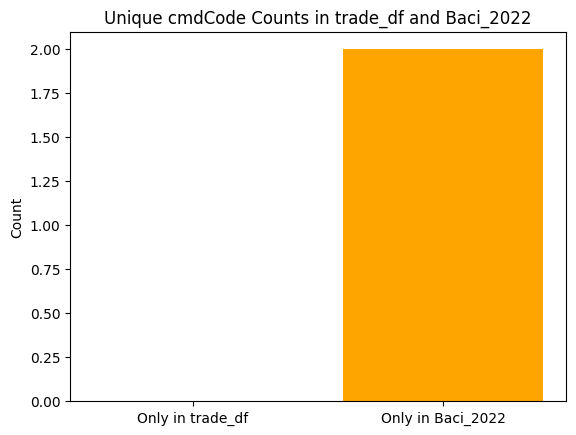

In [62]:
import matplotlib.pyplot as plt

categories = ['Only in trade_df', 'Only in Baci_2022']
counts = [len(cmdcode_only_in_trade), len(cmdcode_only_in_baci)]

plt.bar(categories, counts, color=['blue', 'orange'])
plt.title('Unique cmdCode Counts in trade_df and Baci_2022')
plt.ylabel('Count')
plt.show()
